Original data:
   Hours_Studied  Practice_Tests Result
0              2               1   Fail
1              5               3   Pass
2              8               4   Pass
3              1               1   Fail
4              7               5   Pass
5              3               2   Fail
1. After encoding Pass/Fail:
   Hours_Studied  Practice_Tests  Result
0              2               1       0
1              5               3       1
2              8               4       1
3              1               1       0
4              7               5       1
5              3               2       0

Model trained!

A student who studied for 4 hours and took  practice tests will: Fail


C:\Users\Niomi\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


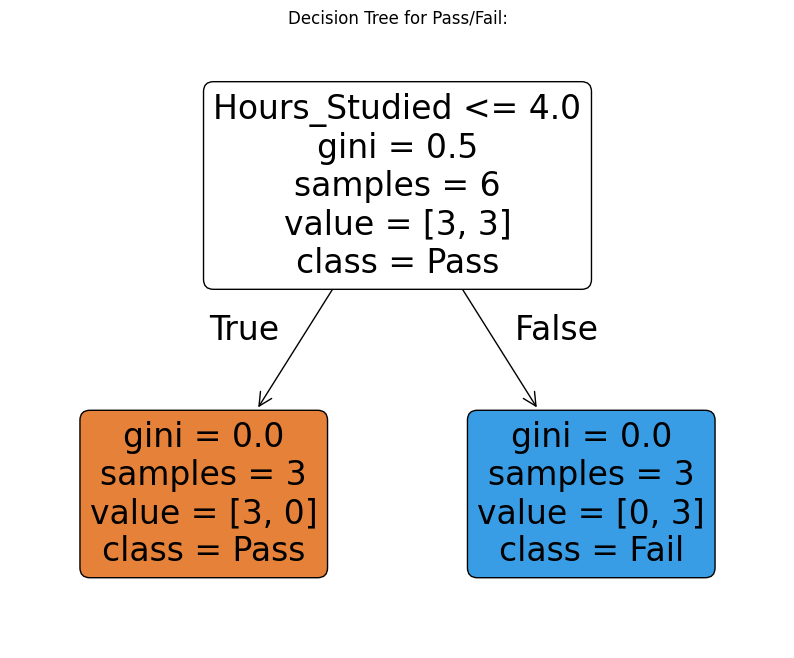

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = {
    'Hours_Studied': [2, 5, 8, 1, 7, 3],
    'Practice_Tests': [1, 3, 4, 1, 5, 2],
    'Result': ['Fail', 'Pass', 'Pass', 'Fail', 'Pass', 'Fail']
}

df = pd.DataFrame(data)
print("Original data:")
print(df)

# Encode the 'Result' column into numbers (Fail=0, Pass=1).
encoder = LabelEncoder()
df['Result'] = encoder.fit_transform(df['Result'])
print("1. After encoding Pass/Fail:")
print(df)

# Set your X (Hours and Tests) and your y (Result).
X = df[['Hours_Studied', 'Practice_Tests']]
y = df['Result']

# Train a DecisionTreeClassifier().
model = DecisionTreeClassifier()

model.fit(X, y)
print("\nModel trained!")

# Predict: If a student studies for 4 hours and takes 2 practice tests, will they Pass or Fail?
new_data = [[4, 2]]

num_prediction = model.predict(new_data)
prediction = encoder.inverse_transform(num_prediction)

print(f"\nA student who studied for 4 hours and took  practice tests will: {prediction[0]}")

# Use plot_tree to visualize the logic.
plt.figure(figsize=(10, 8))

plot_tree(model, feature_names=['Hours_Studied', 'Practice_Tests', 'Result'], class_names=['Pass', 'Fail'], filled=True, rounded=True)
plt.title("Decision Tree for Pass/Fail:")
plt.show()